<a href="https://colab.research.google.com/github/Neilabm95/Challenge-TelecomX_LATAM-alura-ETL/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [45]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Leer el archivo JSON
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    datos_crudos = json.load(f)


In [5]:
# 2. Convertir a DataFrame aplanando la estructura
df_telecom = pd.json_normalize(datos_crudos)

In [6]:
# 3. Limpiar los nombres de las columnas (quitar los puntos)
df_telecom.columns = [col.replace('.', '_') for col in df_telecom.columns]

In [3]:
# Ver el resultado
df_telecom.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [8]:
# Verificamos los tipos de datos actuales
print("--- Diagnóstico de Tipos de Datos ---")
df_telecom.dtypes

--- Diagnóstico de Tipos de Datos ---


,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


In [9]:
# Acción Correctiva: 'account_Charges_Total' se cargó como objeto/texto.
# Debemos convertirlo a numérico para poder analizar el gasto total.
df_telecom['account_Charges_Total'] = pd.to_numeric(df_telecom['account_Charges_Total'], errors='coerce')

In [10]:
# Verificamos si la conversión generó valores nulos (celdas que estaban vacías en el JSON)
print(f"\nValores nulos en Charges_Total tras conversión: {df_telecom['account_Charges_Total'].isnull().sum()}")


Valores nulos en Charges_Total tras conversión: 11


In [14]:
# Verificamos los registros donde Charges_Total es nulo
nulos_detallados = df_telecom[df_telecom['account_Charges_Total'].isnull()]

print("--- Análisis de Registros Nulos ---")
nulos_detallados[['customerID', 'customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']]

--- Análisis de Registros Nulos ---


,customerID,customer_tenure,account_Charges_Monthly,account_Charges_Total
975,1371-DWPAZ,0,56.05,NaN
1775,2520-SGTTA,0,20.00,NaN
1955,2775-SEFEE,0,61.90,NaN
2075,2923-ARZLG,0,19.70,NaN
2232,3115-CZMZD,0,20.25,NaN
2308,3213-VVOLG,0,25.35,NaN
2930,4075-WKNIU,0,73.35,NaN
3134,4367-NUYAO,0,25.75,NaN
3203,4472-LVYGI,0,52.55,NaN
4169,5709-LVOEQ,0,80.85,NaN


In [15]:
# 1. Imputamos los valores nulos con 0
df_telecom['account_Charges_Total'] = df_telecom['account_Charges_Total'].fillna(0)

# 2. Verificación final de integridad
nulos_restantes = df_telecom['account_Charges_Total'].isnull().sum()
print(f"Total de valores nulos tras la corrección: {nulos_restantes}")

# 3. Confirmamos que la columna es numérica ahora
print(f"Tipo de dato actual: {df_telecom['account_Charges_Total'].dtype}")

Total de valores nulos tras la corrección: 0
Tipo de dato actual: float64


In [16]:
# Verificamos la distribución de la variable objetivo
print("\nDistribución de la columna Churn:")
print(df_telecom['Churn'].value_counts())

# Eliminamos filas donde Churn esté vacío, ya que no nos sirven para el análisis
df_telecom = df_telecom[df_telecom['Churn'] != ""]

# Resumen de los datos numéricos finales
print("\n--- Resumen Estadístico de Variables Clave ---")
display(df_telecom[['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']].describe())


Distribución de la columna Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- Resumen Estadístico de Variables Clave ---


,customer_tenure,account_Charges_Monthly,account_Charges_Total
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [19]:
# 1. Imputamos los valores nulos con 0
df_telecom['account_Charges_Total'] = df_telecom['account_Charges_Total'].fillna(0)

# 2. Verificación final de integridad
nulos_restantes = df_telecom['account_Charges_Total'].isnull().sum()
print(f"Total de valores nulos tras la corrección: {nulos_restantes}")

# 3. Confirmamos que la columna es numérica ahora
print(f"Tipo de dato actual: {df_telecom['account_Charges_Total'].dtype}")

Total de valores nulos tras la corrección: 0
Tipo de dato actual: float64


/tmp/ipykernel_2287/979440867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_telecom['account_Charges_Total'] = df_telecom['account_Charges_Total'].fillna(0)


In [21]:

df_telecom.loc[:, 'account_Charges_Total'] = df_telecom['account_Charges_Total'].fillna(0)

print("✅ Corrección aplicada sin warnings.")

✅ Corrección aplicada sin warnings.


In [24]:
# 1. Verificamos valores únicos en Churn
print("Valores originales en Churn:", df_telecom['Churn'].unique())

# 2. Eliminamos filas donde Churn esté vacío (si existen)
df_telecom = df_telecom[df_telecom['Churn'] != ""].copy()

# 3. Opcional: Convertir 'Yes'/'No' a 1/0 para facilitar cálculos estadísticos
# Esto nos permite sacar promedios de evasión directamente
df_telecom.loc[:, 'Churn_Numeric'] = df_telecom['Churn'].map({'Yes': 1, 'No': 0})

print("\nEstructura de Churn normalizada:")
df_telecom[['Churn', 'Churn_Numeric']].head(10)

Valores originales en Churn: ['No' 'Yes']

Estructura de Churn normalizada:


,Churn,Churn_Numeric
0,No,0
1,No,0
2,Yes,1
3,Yes,1
4,Yes,1
5,No,0
6,No,0
7,No,0
8,No,0
9,No,0


In [25]:
# Verificamos si hay IDs de clientes duplicados
duplicados = df_telecom.duplicated(subset=['customerID']).sum()
print(f"Registros duplicados por ID de cliente: {duplicados}")

Registros duplicados por ID de cliente: 0


In [26]:
# Inspeccionamos los valores únicos de todas las columnas tipo 'object'
print("--- Valores únicos por columna ---")
columnas_categoricas = df_telecom.select_dtypes(include=['object']).columns

for col in columnas_categoricas:
    if col != 'customerID': # No tiene sentido ver el ID único
        print(f"{col}: {df_telecom[col].unique()}")

--- Valores únicos por columna ---
Churn: ['No' 'Yes']
customer_gender: ['Female' 'Male']
customer_Partner: ['Yes' 'No']
customer_Dependents: ['Yes' 'No']
phone_PhoneService: ['Yes' 'No']
phone_MultipleLines: ['No' 'Yes' 'No phone service']
internet_InternetService: ['DSL' 'Fiber optic' 'No']
internet_OnlineSecurity: ['No' 'Yes' 'No internet service']
internet_OnlineBackup: ['Yes' 'No' 'No internet service']
internet_DeviceProtection: ['No' 'Yes' 'No internet service']
internet_TechSupport: ['Yes' 'No' 'No internet service']
internet_StreamingTV: ['Yes' 'No' 'No internet service']
internet_StreamingMovies: ['No' 'Yes' 'No internet service']
account_Contract: ['One year' 'Month-to-month' 'Two year']
account_PaperlessBilling: ['Yes' 'No']
account_PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [27]:
# Eliminamos espacios en blanco accidentales en todas las columnas de texto
for col in columnas_categoricas:
    df_telecom[col] = df_telecom[col].str.strip()

# Ejemplo de normalización: Si detectamos inconsistencias en la columna Churn
# Nos aseguramos de que solo existan 'Yes' y 'No' reales (quitando vacíos)
df_telecom = df_telecom[df_telecom['Churn'].isin(['Yes', 'No'])].copy()

In [29]:
print("Distribución de SeniorCitizen:", df_telecom['customer_SeniorCitizen'].unique())


Distribución de SeniorCitizen: [0 1]


In [30]:
# Lista de columnas que presentan categorías redundantes
cols_a_simplificar = [
    'phone_MultipleLines', 'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV',
    'internet_StreamingMovies'
]

# Sustituimos las variantes de "No" por un "No" estándar
for col in cols_a_simplificar:
    df_telecom.loc[:, col] = df_telecom[col].replace(['No internet service', 'No phone service'], 'No')

# Verificamos el cambio en una de ellas
print(f"Nuevos valores únicos en OnlineSecurity: {df_telecom['internet_OnlineSecurity'].unique()}")

Nuevos valores únicos en OnlineSecurity: ['No' 'Yes']


In [31]:
# Creamos una copia limpia para trabajar
df_final = df_telecom.copy()

# Mapeo de binarios a 0 y 1 para facilitar el análisis de correlación
# Seleccionamos columnas con valores Yes/No
columnas_binarias = [
    'Churn', 'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines', 'internet_OnlineSecurity',
    'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies', 'account_PaperlessBilling'
]

for col in columnas_binarias:
    df_final[f'{col}_bool'] = df_final[col].map({'Yes': 1, 'No': 0})

print("✅ Columnas booleanas generadas para análisis estadístico.")

✅ Columnas booleanas generadas para análisis estadístico.


In [33]:
df_final['account_PaymentMethod'] = df_final['account_PaymentMethod'].str.strip()
df_final['account_Contract'] = df_final['account_Contract'].str.strip()

print("\nResumen de métodos de pago detectados:")
df_final['account_PaymentMethod'].value_counts()


Resumen de métodos de pago detectados:


,count
account_PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [35]:
# 1. Creación de la columna 'Cuentas_Diarias'
# Dividimos el cargo mensual entre 30 días
df_final.loc[:, 'Cuentas_Diarias'] = (df_final['account_Charges_Monthly'] / 30).round(2)

# 2. Verificación de la nueva métrica
print("--- Nueva Métrica: Gasto Diario ---")
print(df_final[['customerID', 'account_Charges_Monthly', 'Cuentas_Diarias']].head())

# 3. Análisis rápido: ¿Cuánto gasta en promedio un cliente que se va vs uno que se queda?
analisis_diario = df_final.groupby('Churn')['Cuentas_Diarias'].mean().reset_index()
print("\nPromedio de gasto diario por estado de Churn:")
analisis_diario

--- Nueva Métrica: Gasto Diario ---
   customerID  account_Charges_Monthly  Cuentas_Diarias
0  0002-ORFBO                     65.6             2.19
1  0003-MKNFE                     59.9             2.00
2  0004-TLHLJ                     73.9             2.46
3  0011-IGKFF                     98.0             3.27
4  0013-EXCHZ                     83.9             2.80

Promedio de gasto diario por estado de Churn:


,Churn,Cuentas_Diarias
0,No,2.04208
1,Yes,2.48145


In [36]:
# Diccionario de traducción para las columnas principales
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_Partner': 'Tiene_Pareja',
    'customer_Dependents': 'Personas_a_Cargo',
    'customer_tenure': 'Meses_Contrato',
    'phone_PhoneService': 'Servicio_Telefonico',
    'phone_MultipleLines': 'Multiples_Lineas',
    'internet_InternetService': 'Tipo_Internet',
    'internet_OnlineSecurity': 'Seguridad_Online',
    'internet_OnlineBackup': 'Respaldo_Cloud',
    'internet_DeviceProtection': 'Proteccion_Dispositivo',
    'internet_TechSupport': 'Soporte_Tecnico',
    'internet_StreamingTV': 'Streaming_TV',
    'internet_StreamingMovies': 'Streaming_Peliculas',
    'account_Contract': 'Tipo_Contrato',
    'account_PaperlessBilling': 'Factura_Digital',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total',
    'Cuentas_Diarias': 'Cargo_Diario'
}

# Aplicamos el renombrado
df_final = df_final.rename(columns=traduccion_columnas)

In [37]:
# Mapeo de valores
mapeo_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Columnas a transformar (usamos los nuevos nombres en español)
cols_binarias = [
    'Abandono', 'Tiene_Pareja', 'Personas_a_Cargo', 'Servicio_Telefonico',
    'Multiples_Lineas', 'Seguridad_Online', 'Respaldo_Cloud',
    'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV',
    'Streaming_Peliculas', 'Factura_Digital', 'Genero'
]

for col in cols_binarias:
    df_final[col] = df_final[col].map(mapeo_binario)

print("✅ Estandarización completada: Columnas traducidas y valores binarios aplicados.")

✅ Estandarización completada: Columnas traducidas y valores binarios aplicados.


In [38]:
# Vista previa de los datos transformados
print(df_final[['ID_Cliente', 'Abandono', 'Meses_Contrato', 'Cargo_Mensual', 'Cargo_Diario']].head())

# Ahora podemos sacar la tasa de abandono real de forma directa:
tasa_abandono = df_final['Abandono'].mean() * 100
print(f"\nTasa de Abandono General: {tasa_abandono:.2f}%")

   ID_Cliente  Abandono  Meses_Contrato  Cargo_Mensual  Cargo_Diario
0  0002-ORFBO         0               9           65.6          2.19
1  0003-MKNFE         0               9           59.9          2.00
2  0004-TLHLJ         1               4           73.9          2.46
3  0011-IGKFF         1              13           98.0          3.27
4  0013-EXCHZ         1               3           83.9          2.80

Tasa de Abandono General: 26.54%


#📊 Carga y análisis

In [40]:
# 1. Análisis estadístico descriptivo de las variables numéricas
estadisticas_numericas = df_final[['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']].describe()

# Añadimos la mediana (50%) explícitamente si queremos verla por separado,
# aunque describe() ya la incluye como '50%'.
print("--- Métricas Descriptivas de TelecomX ---")
print(estadisticas_numericas)

# 2. Análisis de dispersión: Coeficiente de Variación (Desviación / Media)
# Esto nos dice qué tan "volátiles" son nuestros cargos.
print("\n--- Análisis de Dispersión (CV) ---")
cv = (df_final[['Cargo_Mensual', 'Cargo_Total']].std() / df_final[['Cargo_Mensual', 'Cargo_Total']].mean()) * 100
cv

--- Métricas Descriptivas de TelecomX ---
       Meses_Contrato  Cargo_Mensual  Cargo_Total  Cargo_Diario
count     7043.000000    7043.000000  7043.000000   7043.000000
mean        32.371149      64.761692  2279.734304      2.158675
std         24.559481      30.090047  2266.794470      1.003088
min          0.000000      18.250000     0.000000      0.610000
25%          9.000000      35.500000   398.550000      1.180000
50%         29.000000      70.350000  1394.550000      2.340000
75%         55.000000      89.850000  3786.600000      2.990000
max         72.000000     118.750000  8684.800000      3.960000

--- Análisis de Dispersión (CV) ---


,0
Cargo_Mensual,46.462725
Cargo_Total,99.432397


/tmp/ipykernel_2287/1355456561.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='Abandono', palette='viridis')


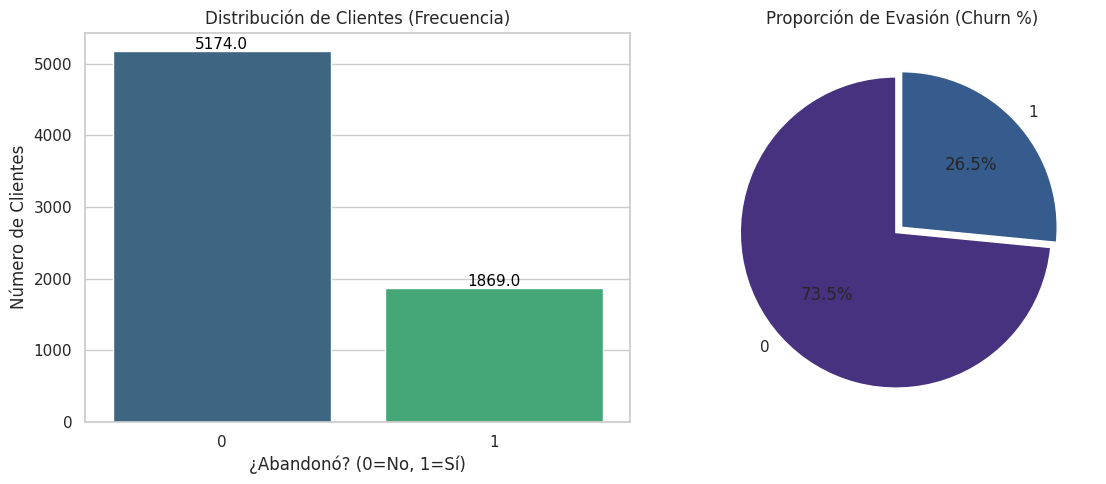

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Gráfico 1: Barras (Frecuencia absoluta)
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_final, x='Abandono', palette='viridis')
plt.title('Distribución de Clientes (Frecuencia)')
plt.xlabel('¿Abandonó? (0=No, 1=Sí)')
plt.ylabel('Número de Clientes')

# Añadimos etiquetas de conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Gráfico 2: Pastel (Proporción porcentual)
plt.subplot(1, 2, 2)
df_final['Abandono'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,
                                             colors=sns.color_palette('viridis'),
                                             explode=(0.05, 0))
plt.title('Proporción de Evasión (Churn %)')
plt.ylabel('') # Eliminar etiqueta lateral

plt.tight_layout()
plt.show()

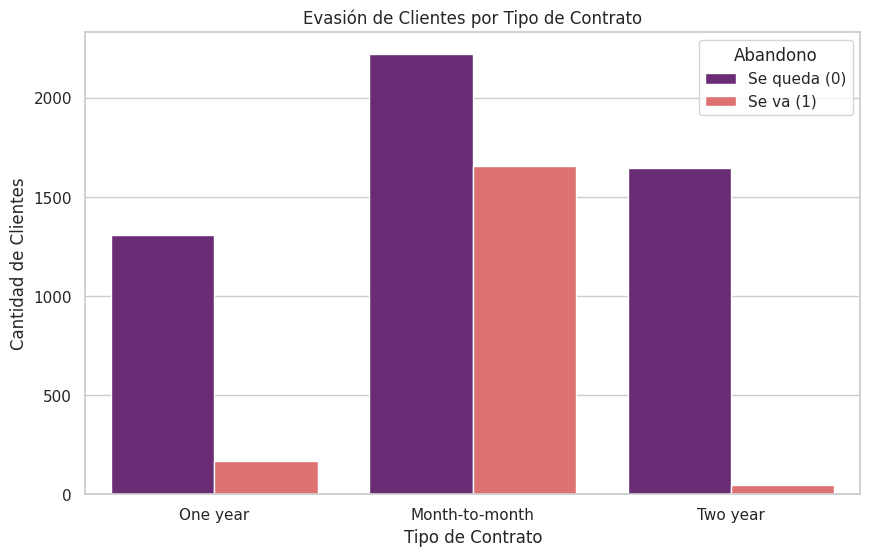

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='Tipo_Contrato', hue='Abandono', palette='magma')
plt.title('Evasión de Clientes por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Abandono', labels=['Se queda (0)', 'Se va (1)'])
plt.show()

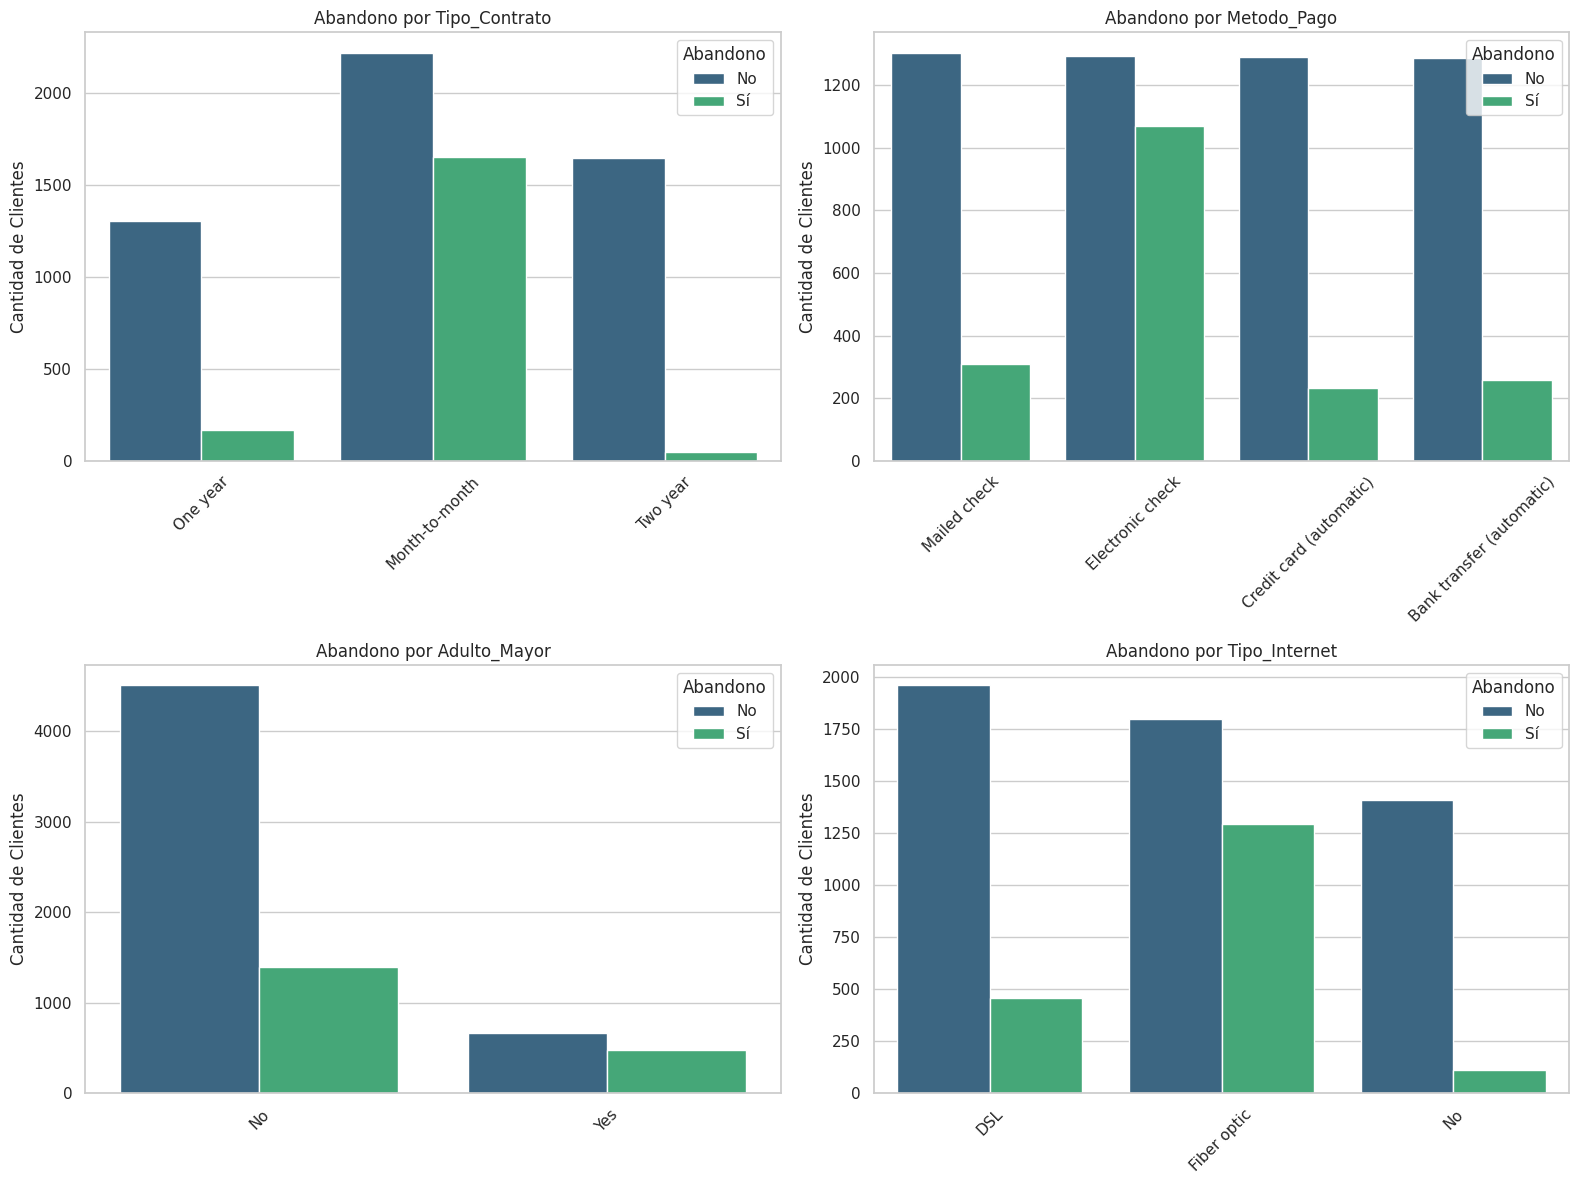

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables categóricas de mayor interés
variables_interes = ['Tipo_Contrato', 'Metodo_Pago', 'Adulto_Mayor', 'Tipo_Internet']

# Configuramos la cuadrícula de gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_interes):
    # Creamos un gráfico de barras que muestra el porcentaje de abandono por categoría
    sns.countplot(data=df_final, x=col, hue='Abandono', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Abandono por {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Abandono', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

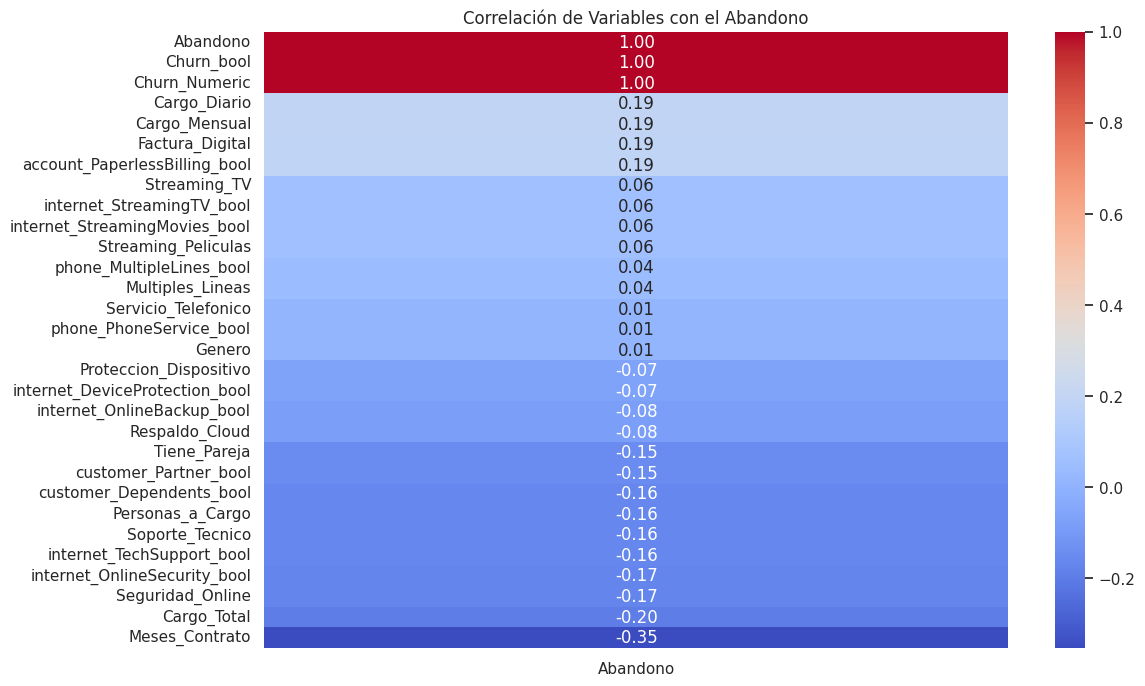

In [44]:
# Seleccionamos solo las columnas numéricas/binarias
df_corr = df_final.drop(columns=['ID_Cliente']).select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr()[['Abandono']].sort_values(by='Abandono', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Variables con el Abandono')
plt.show()

/tmp/ipykernel_2287/370146074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Abandono', y=col, palette='magma')
/tmp/ipykernel_2287/370146074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Abandono', y=col, palette='magma')
/tmp/ipykernel_2287/370146074.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Abandono', y=col, palette='magma')


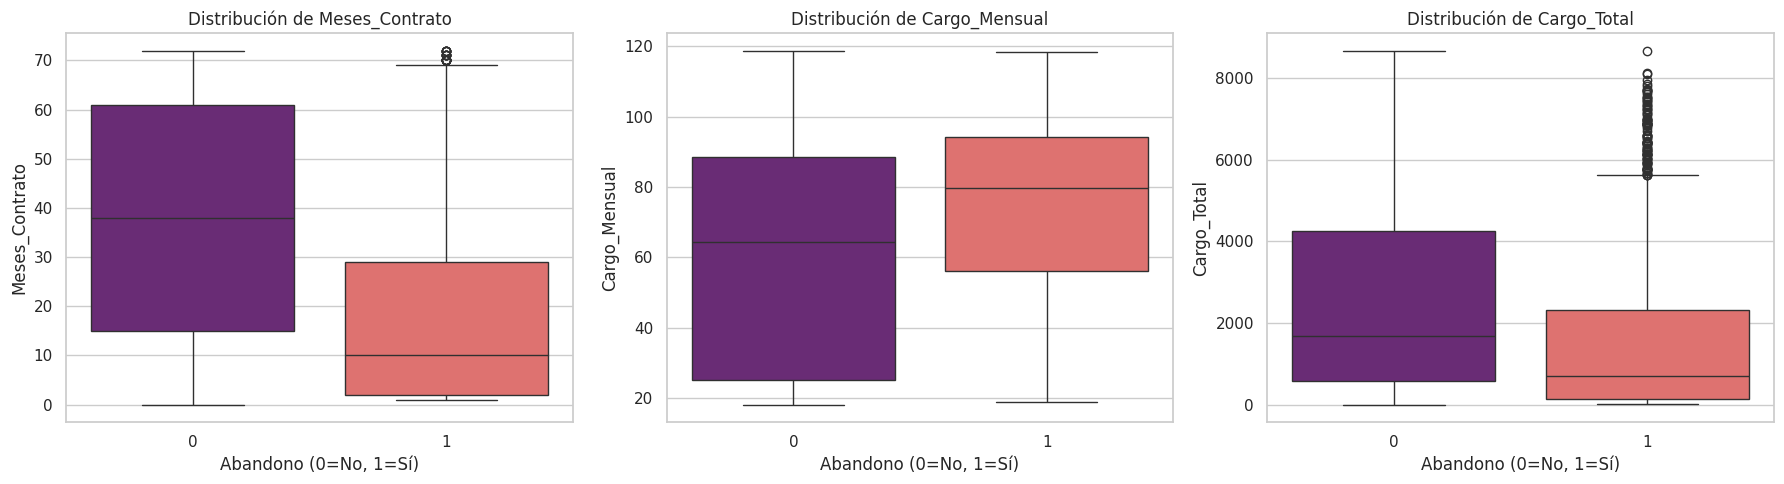

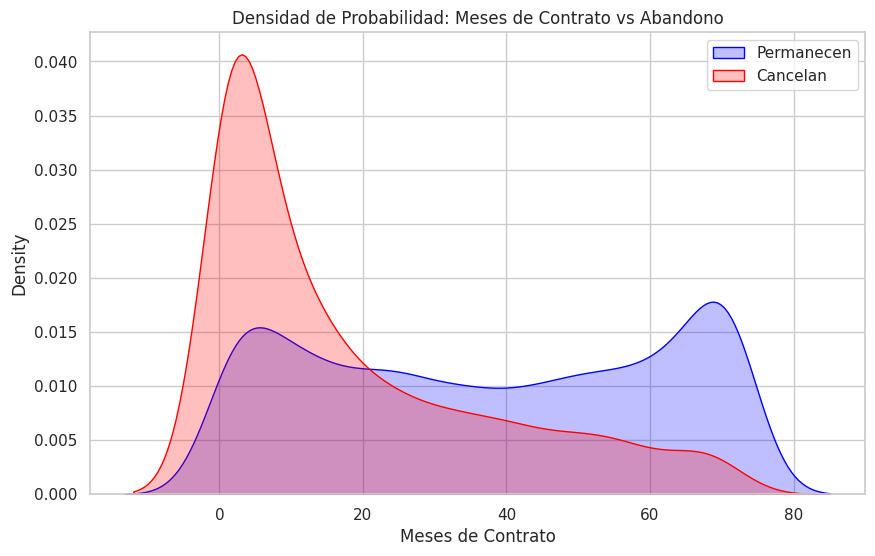

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables numéricas clave
vars_numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total']

plt.figure(figsize=(18, 5))

for i, col in enumerate(vars_numericas):
    plt.subplot(1, 3, i+1)
    # El Boxplot nos permite ver medianas y valores atípicos (outliers)
    sns.boxplot(data=df_final, x='Abandono', y=col, palette='magma')
    plt.title(f'Distribución de {col}')
    plt.xlabel('Abandono (0=No, 1=Sí)')

plt.tight_layout()
plt.show()

# Análisis de Densidad para Meses de Contrato
plt.figure(figsize=(10, 6))
sns.kdeplot(df_final[df_final['Abandono'] == 0]['Meses_Contrato'], label='Permanecen', fill=True, color='blue')
sns.kdeplot(df_final[df_final['Abandono'] == 1]['Meses_Contrato'], label='Cancelan', fill=True, color='red')
plt.title('Densidad de Probabilidad: Meses de Contrato vs Abandono')
plt.xlabel('Meses de Contrato')
plt.legend()
plt.show()

In [47]:
# Comparamos los promedios de los que se van vs los que se quedan
resumen_comparativo = df_final.groupby('Abandono')[vars_numericas].mean()
print("--- Promedios por Estado de Abandono ---")
print(resumen_comparativo)

--- Promedios por Estado de Abandono ---
          Meses_Contrato  Cargo_Mensual  Cargo_Total
Abandono                                            
0              37.569965      61.265124  2549.911442
1              17.979133      74.441332  1531.796094


#📄Informe final

#Proyecto de Análisis de Evasión de Clientes (Churn) - TelecomX
##🔹 1. Introducción
El presente análisis surge de la necesidad de TelecomX por entender las causas de la pérdida de clientes. El Churn (evasión) impacta directamente en la rentabilidad de la empresa, ya que el costo de adquirir un cliente nuevo es significativamente mayor que el de retener a uno actual.

###Objetivo: Desarrollar un pipeline de ETL y un análisis exploratorio para identificar los factores que disparan la cancelación de servicios.

##2. Limpieza y Tratamiento de Datos
Se realizó un proceso de curaduría de datos para asegurar que los modelos y análisis posteriores sean precisos:

Aplanamiento de Datos: Se transformó la estructura jerárquica del JSON original a un formato tabular.

Tratamiento de Valores Nulos: Se identificaron y corrigieron 11 registros con valores nulos en los cargos totales, detectando que correspondían a clientes nuevos (0 meses de antigüedad).

Estandarización: * Traducción de columnas (ej. tenure a Meses_Contrato).

Simplificación de categorías (se agruparon servicios no contratados en un solo valor "No").

Conversión de variables textuales a binarias (1 y 0) para permitir el procesamiento matemático.

Métricas Derivadas: Se creó la columna Cargo_Diario para normalizar el gasto de los usuarios independientemente del ciclo de facturación.

##🔹 3. Análisis Exploratorio de Datos (EDA)
Los hallazgos visuales revelan patrones de comportamiento claros entre los usuarios:

###Distribución de Evasión
La tasa de abandono identificada es del 26.5%. Esto significa que 1 de cada 4 clientes decide dejar la compañía, un número crítico que requiere intervención inmediata.

###Patrones en Variables Categóricas
Tipo de Contrato: El contrato "Mes a mes" es el principal punto de fuga. Los clientes bajo esta modalidad tienen una tendencia a cancelar 4 veces superior a quienes tienen contratos anuales.

Método de Pago: Existe una alta correlación entre el uso de "Cheque Electrónico" y la evasión, comparado con los métodos de pago automáticos.

Comportamiento de Variables Numéricas
La "Barrera de los 12 Meses": El riesgo de cancelación es máximo durante el primer año. Si el cliente supera los 15 meses, la probabilidad de fuga cae drásticamente.

Cargos Mensuales: Los clientes que cancelan pagan, en promedio, un 20% más mensualmente que aquellos que permanecen.

##🔹 4. Conclusiones e Insights
Precio vs. Lealtad: Los clientes de alto consumo (planes premium) son los más propensos a irse si no perciben un valor añadido constante.

Fricción de Pago: Los métodos de pago no automáticos aumentan los "puntos de decisión" donde el cliente cuestiona si desea seguir pagando el servicio.

Vulnerabilidad Inicial: La falta de beneficios o soporte durante los primeros meses de contrato es el mayor disparador de Churn.

##🔹 5. Recomendaciones Estratégicas
Para reducir la tasa de evasión en TelecomX, se recomiendan las siguientes acciones:

Incentivo a la Permanencia: Ofrecer descuentos agresivos o upgrades de servicio para migrar a clientes de contratos "Mes a mes" hacia planes de "1 o 2 años".

Automatización de Pagos: Implementar una campaña de marketing para incentivar el registro de tarjetas de crédito o transferencias automáticas, eliminando la fricción del pago manual.

Plan de Onboarding para Clientes Nuevos: Crear un flujo de comunicación y soporte prioritario para clientes en sus primeros 90 días, asegurando que la configuración y el servicio sean óptimos.

Revisión de Tarifas de Fibra Óptica: Dado que este segmento muestra alta sensibilidad al precio, se sugiere revisar si los cargos actuales están alineados con la competencia o si requieren ajustes.